<a href="https://colab.research.google.com/github/Omar-RojasGBF/lis5693/blob/main/lab-8/Lab_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%%capture
!pip install bertopic datasets openai datamapplot

In [23]:
import requests
import io
import pandas as pd

url = "https://raw.githubusercontent.com/Omar-RojasGBF/lis5693/refs/heads/main/lab-5/lens-export.csv"
response = requests.get(url)
response.raise_for_status()

df = pd.read_csv(io.StringIO(response.text))

abstracts = list(df["Abstract"])
titles = list(df["Title"])

In [25]:
from sentence_transformers import SentenceTransformer
import numpy as np

embedding_model = SentenceTransformer('thenlper/gte-small')


processed_abstracts = [str(x) if not (isinstance(x, float) and np.isnan(x)) else "" for x in abstracts]

embeddings = embedding_model.encode(processed_abstracts, show_progress_bar=True)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: thenlper/gte-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

In [27]:
embeddings.shape

(1000, 384)

In [28]:
from umap import UMAP

umap_model = UMAP(
    n_components=5, min_dist=0.0, metric='cosine', random_state=42
)
reduced_embeddings = umap_model.fit_transform(embeddings)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [29]:
from hdbscan import HDBSCAN

hdbscan_model = HDBSCAN(
    min_cluster_size=50, metric='euclidean', cluster_selection_method='eom'
).fit(reduced_embeddings)
clusters = hdbscan_model.labels_

len(set(clusters))

3

In [31]:
import numpy as np

cluster = 0
for index in np.where(clusters==cluster)[0][:3]:
    print(processed_abstracts[index][:300] + "... \n")

... 

... 

... 



In [32]:
import pandas as pd

reduced_embeddings = UMAP(
    n_components=2, min_dist=0.0, metric='cosine', random_state=42
).fit_transform(embeddings)

df = pd.DataFrame(reduced_embeddings, columns=["x", "y"])
df["title"] = titles
df["cluster"] = [str(c) for c in clusters]

clusters_df = df.loc[df.cluster != "-1", :]
outliers_df = df.loc[df.cluster == "-1", :]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(np.float64(-14.299381732940674),
 np.float64(13.264788150787354),
 np.float64(-4.501782548427582),
 np.float64(9.943866145610809))

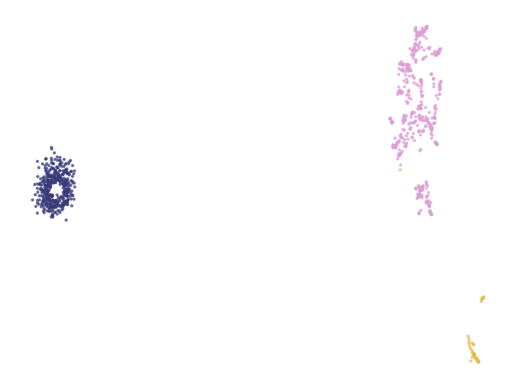

In [33]:
import matplotlib.pyplot as plt

plt.scatter(outliers_df.x, outliers_df.y, alpha=0.05, s=2, c="grey")
plt.scatter(
    clusters_df.x, clusters_df.y, c=clusters_df.cluster.astype(int),
    alpha=0.6, s=2, cmap='tab20b'
)
plt.axis('off')

In [35]:
from bertopic import BERTopic

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    verbose=True
).fit(processed_abstracts, embeddings)

2026-04-23 10:00:35,056 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-23 10:00:43,690 - BERTopic - Dimensionality - Completed ✓
2026-04-23 10:00:43,691 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-23 10:00:43,720 - BERTopic - Cluster - Completed ✓
2026-04-23 10:00:43,725 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-23 10:00:43,816 - BERTopic - Representation - Completed ✓


In [36]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,0,507,0_the_and_of_cancer,"[the, and, of, cancer, in, to, for, with, is, ...","[<AbstractText Label=""PURPOSE"" NlmCategory=""OB..."
1,1,425,1_his_he_the_to,"[his, he, the, to, and, mr, field, about, at, of]",[<jats:title>Abstract</jats:title><jats:p>Chem...
2,2,68,2_and_of_the_to,"[and, of, the, to, for, is, jats, on, suppleme...",[Data sharing is essential for reproducibility...


In [37]:
topic_model.get_topic(0)

[('the', np.float64(0.1048884857872494)),
 ('and', np.float64(0.09757041288553946)),
 ('of', np.float64(0.09234046793850212)),
 ('cancer', np.float64(0.0822478389363178)),
 ('in', np.float64(0.08000446234177735)),
 ('to', np.float64(0.060484164119243795)),
 ('for', np.float64(0.044134851947383404)),
 ('with', np.float64(0.036232605672523004)),
 ('is', np.float64(0.029870693238655856)),
 ('were', np.float64(0.028741717631751092))]

In [38]:
topic_model.find_topics("topic modeling")

([2, 1, 0],
 [np.float64(0.8702890703905466),
  np.float64(0.8357478295404548),
  np.float64(0.8338264076274395)])

In [39]:
topic_model.get_topic(22)

False

In [42]:
topic_model.topics_[titles.index('BERTopic: Neural topic modeling with a class-based TF-IDF procedure')]

ValueError: 'BERTopic: Neural topic modeling with a class-based TF-IDF procedure' is not in list

In [43]:
fig = topic_model.visualize_documents(
    titles,
    reduced_embeddings=reduced_embeddings,
    width=1200,
    hide_annotations=True
)

fig.update_layout(font=dict(size=16))

In [45]:
topic_model.visualize_barchart()

topic_model.visualize_heatmap(n_clusters=2)

topic_model.visualize_hierarchy()

I noticed a lot more words like "the" and "and" appearing this time than in Lab 5. This is most likely due to I cleaned my data in Lab 5 to prevent stop words and punctuation from appearing in ym results. I also feel like this lab's results were a smaller scale than lab 5's results. Since are clustering out text data, it might be natural for the final result to be smaller than the results of sentiment analysis.

Reflection 💭


---
I think my Google colab final works well again; I had major issues with running my code. I had to do some internet searching to know how to extract metadata from my csv file. I think I can see myself using large language models or embeddings right if libraries decide in integrate more AI models for search queries or recommondations.
